# Early Stage Diabetes Risk Prediction

**Murlidhar Ravi Geetha Varma — 2025AC05598**
Machine Learning, Assignment 2

Implementing 5 classification models compared on the UCI Early Stage Diabetes Risk Prediction dataset
(ID 529): logistic regression, a decision tree, k-nearest neighbours, Gaussian naive Bayes,
and a random forest. Each is scored on accuracy, AUC, precision, recall, F1 and Matthews
correlation coefficient.

Providing the UCI link below for more details on the dataset:
https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset

In [19]:
import sys
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 9})
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)
ACCENT = "#D85A30"


for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").is_dir():
        sys.path.insert(0, str(candidate))
        break

## 1. Exploratory data analysis

### 1.1 Structure and completeness

In [20]:
from src.config import FEATURES, SYMPTOM_FEATURES, TARGET
from src.data import load_data

raw = load_data()

print(f"{raw.shape[0]} instances, {raw.shape[1] - 1} features, 1 target")
print(f"Missing values: {int(raw.isna().sum().sum())}")
print(f"Age range: {raw['Age'].min()}-{raw['Age'].max()}")
raw.head()

520 instances, 16 features, 1 target
Missing values: 0
Age range: 16-90


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


520 instances and 16 features (statisfies assignment minimums of 500 and 12), but with little margin — no feature is dropped anywhere below. 
- 1 feature is continuous (`Age`), 
- 1 is Male/Female (`Gender`), 
- and the remaining 14 are Yes/No symptom indicators. 
- Nothing is missing.

### 1.2 Class distribution

In [21]:
counts = raw[TARGET].value_counts()
baseline = counts.max() / len(raw)

print(counts.to_string())
print(f"\nMajority class: {baseline:.4f} of records")
print(f"Always predicting '{counts.idxmax()}' therefore scores {baseline:.4f} accuracy")

class
Positive    320
Negative    200

Majority class: 0.6154 of records
Always predicting 'Positive' therefore scores 0.6154 accuracy


The classes are uneven. Any accuracy figure below is read against that 61.5% (if model predicts the majority class unconditionally attains that accuracy ;))

### 1.3 Duplicate records

The finding that determines how every model below is evaluated.

In [22]:
duplicated = int(raw.duplicated().sum())
distinct = raw.drop_duplicates()

# If a repeated response profile carried both labels, the repetition would be
# contradictory labelling, which needs a different remedy from leakage.
conflicting = int((raw.groupby(FEATURES, observed=True)[TARGET].nunique() > 1).sum())

print(f"Exact duplicate rows:      {duplicated} of {len(raw)}")
print(f"Distinct response profiles: {len(distinct)}")
print(f"Profiles with both labels:  {conflicting}")
print(f"\nClass balance after deduplication: "
      f"{distinct[TARGET].value_counts(normalize=True).max():.4f} majority")

Exact duplicate rows:      269 of 520
Distinct response profiles: 251
Profiles with both labels:  0

Class balance after deduplication: 0.6892 majority


More than half the records repeat another record exactly, leaving 251 distinct response
profiles. No profile carries both labels, so this is repetition rather than inconsistent
labelling.

The consequence is that a conventional `train_test_split` places identical rows on both sides
of the split. A model that memorises a training row then scores it correctly in the test set
without having generalised at all, and the high accuracies commonly reported on this dataset
partly reflect that. Deduplication before splitting is therefore have to be applied throughout

Deduplication also worsens the imbalance, from 61.5% to 68.9% majority, which raises the
accuracy floor the models must clear.

### 1.4 Feature–target association

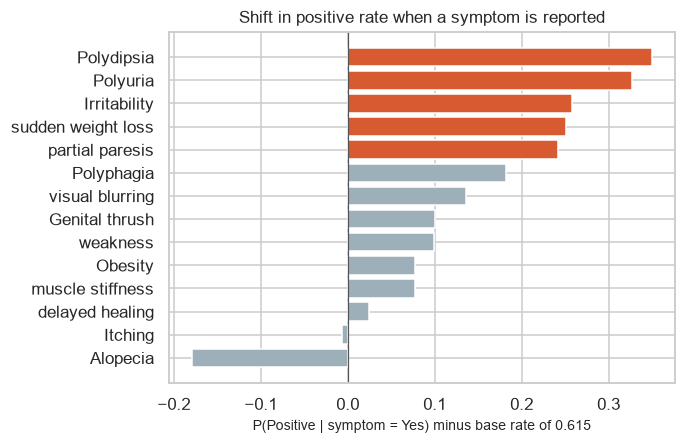

           symptom     shift  positive_rate
        Polydipsia  0.350281       0.965665
          Polyuria  0.326476       0.941860
      Irritability  0.257631       0.873016
sudden weight loss  0.250975       0.866359
   partial paresis  0.241758       0.857143
        Polyphagia  0.182084       0.797468
   visual blurring  0.135688       0.751073
    Genital thrush  0.100133       0.715517
          weakness  0.099369       0.714754
           Obesity  0.077797       0.693182
  muscle stiffness  0.076923       0.692308
   delayed healing  0.024783       0.640167
           Itching -0.006689       0.608696
          Alopecia -0.179630       0.435754


In [23]:
"""
Since symptom features are binary, we can compute the probability of a positive label given that a symptom is reported
This should gives us a measure of association between each symptom and the target.
"""
positive = raw[TARGET].eq("Positive")
base_rate = positive.mean()

sf_mean_ds = pd.Series({c: positive[raw[c].eq("Yes")].mean() for c in SYMPTOM_FEATURES});
association = (
    sf_mean_ds.copy()
    .sub(base_rate)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.barh(association.index, association.values,
        color=[ACCENT if abs(v) > 0.2 else "#9DB0BA" for v in association.values])
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel(f"P(Positive | symptom = Yes) minus base rate of {base_rate:.3f}")
ax.set_title("Shift in positive rate when a symptom is reported")
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "symptom": association.index,
    "shift": association.values,
    "positive_rate": sf_mean_ds[association.index].values
})
print(df.sort_values("positive_rate", ascending=False).reset_index(drop=True).to_string(index=False))

Reporting polyuria or polydipsia moves the positive rate to 0.94 and 0.96 against a base rate
of 0.615. Both are feature presenting symptoms of diabetes, so this is not target leakage —
but it does mean the task is easy, and that a high score is the expected outcome for any
correctly implemented classifier rather than evidence of a strong one.

Alopecia moves the rate downwards, and itching barely moves it at all.

### 1.5 Feature correlation

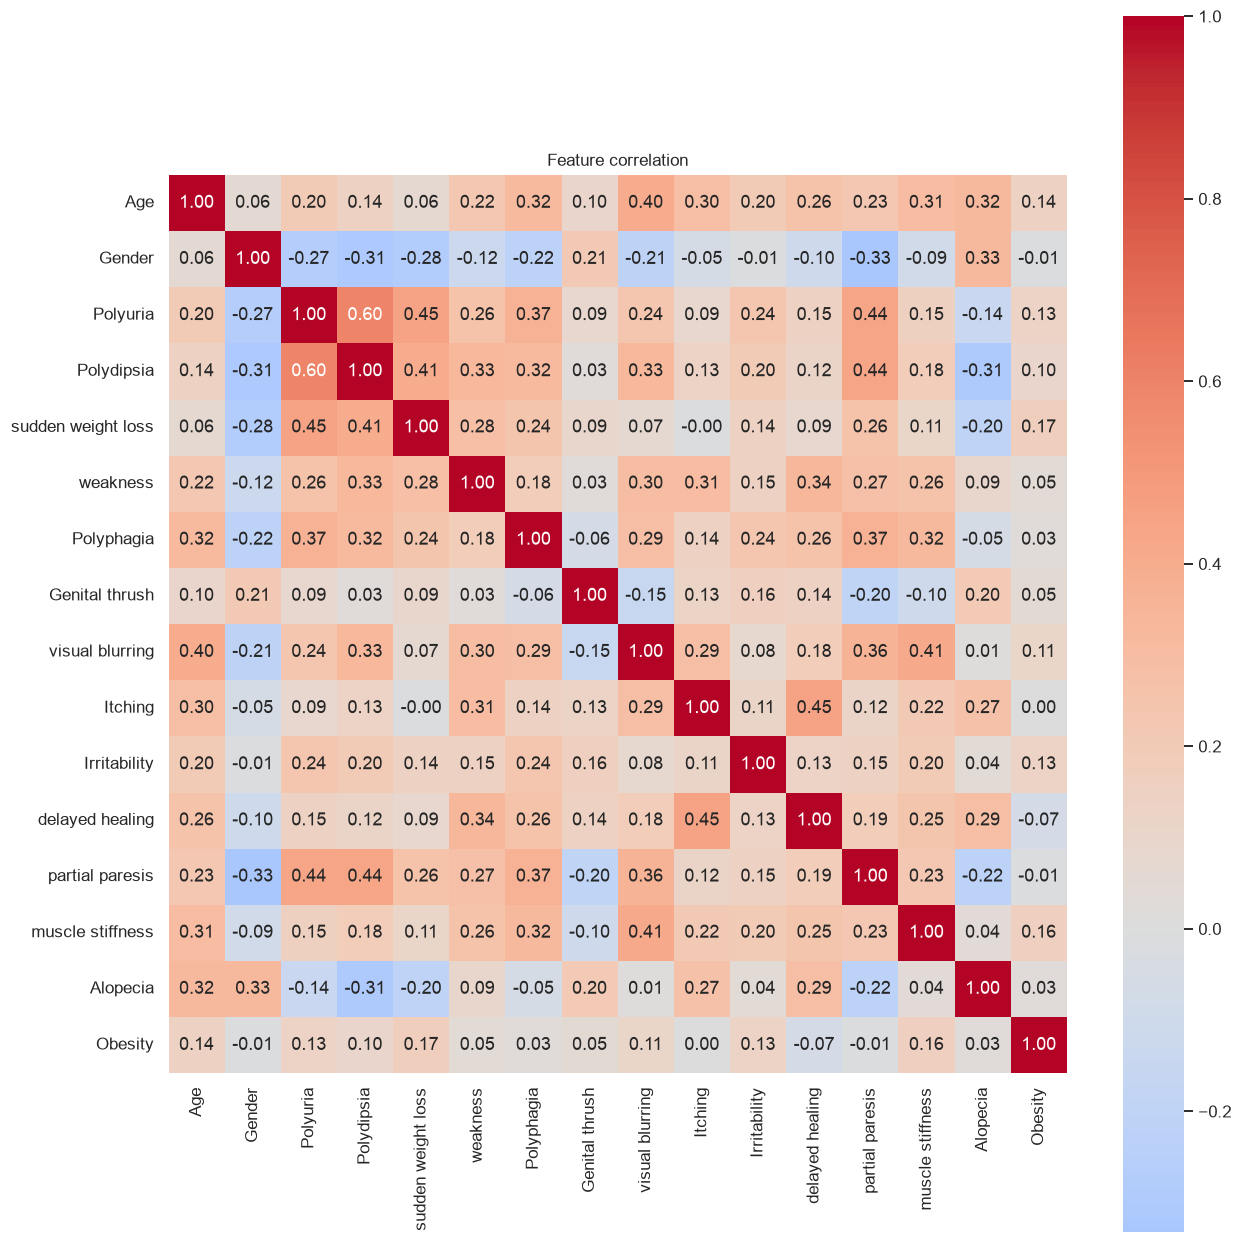

Strongest feature pairs:
Polyuria  Polydipsia            0.598609
Itching   delayed healing       0.453316
Polyuria  sudden weight loss    0.447207


In [24]:
from src.data import encode_features

encoded = encode_features(raw)
correlation = encoded[FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

pairs = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool)).stack()
print("Strongest feature pairs:")
print(pairs.abs().sort_values(ascending=False).head(3).to_string())

Polyuria and polydipsia correlate at 0.60, the strongest of the 120 feature pairs and the only
one above 0.5. This bears directly on Naive Bayes, which assumes the features are conditionally
independent given the class, treating the two strongest predictors as independent evidence
counts substantially the same signal twice and produces overconfident posteriors. The prediction
that naive Bayes underperforms is therefore made before any model is fitted.

### 1.6 Key Decisions Taken

| Observation | Consequence |
|---|---|
| 269 of 520 rows are exact duplicates | Deduplicate before splitting, so no response profile appears on both sides |
| Majority class is 61.5%, rising to 68.9% after deduplication | Lead with MCC; quote accuracy against its floor |
| Polyuria and polydipsia nearly determine the outcome | High scores are unremarkable and must be framed as such |
| Polyuria and polydipsia correlate at 0.60 | Naive Bayes' independence assumption is violated |
| `Age` spans 16–90 against fifteen 0/1 columns, and separates the classes weakly | Scale it for the distance-based and penalised models only |

## 2. Preprocessing and split

Encoding uses fixed maps rather than a fitted encoder. A fitted encoder derives its categories
from whatever frame it is given, so an uploaded file whose polyuria column happened to contain
only "Yes" would encode that as 0 and invert the column against training. `.map()` is used
rather than `.replace()` so an unrecognised value becomes NaN, which scikit-learn rejects,
instead of passing through silently.

In [25]:
from src.config import SEED, TEST_SIZE
from src.data import make_split

X_train, X_test, y_train, y_test = make_split(encoded, deduplicate=True)
test_baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Stratified {int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)} split of the "
      f"{len(encoded.drop_duplicates())} distinct profiles, seed {SEED}")
print(f"Train: {len(X_train)} rows, {int(y_train.sum())} Positive")
print(f"Test:  {len(X_test)} rows, {int(y_test.sum())} Positive")
print(f"Test-set majority baseline: {test_baseline:.4f} accuracy, 0.000 MCC")

Stratified 70/30 split of the 251 distinct profiles, seed 5598
Train: 175 rows, 121 Positive
Test:  76 rows, 52 Positive
Test-set majority baseline: 0.6842 accuracy, 0.000 MCC


The split is stratified because the classes are uneven and the dataset is small enough that an
unstratified draw shifts the test-set balance noticeably. 30% rather than the more common 20%
is held out because deduplication leaves only 251 rows: at 20% each individual test record
would be worth two points of accuracy.

## 3. Model training

Every model is wrapped in a `Pipeline`. This is a correctness requirement rather than a
convenience. Fitting a scaler on the full dataset before splitting lets the test set contribute
to the mean and variance that the training data is standardised by — leakage that inflates the
score with nothing in the code to indicate it happened. Inside a pipeline the scaler is refitted
on the training portion of each cross-validation fold automatically.

Only `Age` is scaled, via `ColumnTransformer`. The other fifteen features are already 0/1, and
standardising them would spread each into an arbitrary range without changing any model's
decisions. Scaling is applied only where the algorithm is sensitive to it: to k-nearest
neighbours, whose Euclidean distance would otherwise be dominated by the widest-ranging and
least informative feature, and to logistic regression, whose penalty shrinks coefficients by
magnitude. Trees split within one feature at a time and Gaussian naive Bayes fits a mean and
variance per feature, so neither is affected by scale.

Gaussian rather than multinomial naive Bayes: multinomial models count data, and `Age` is a
continuous measurement whose magnitude would dominate the likelihood against fifteen binary
indicators.

In [26]:
from src.models import build_pipelines
from sklearn import set_config

pipelines = build_pipelines()
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

pipelines["Logistic Regression"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Gender','Polyuria',...,'muscle stiffness','Alopecia','Obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [27]:
pipelines["Decision Tree"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Gender','Polyuria',...,'muscle stiffness','Alopecia','Obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",5598
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


In [28]:
pipelines["kNN"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Gender','Polyuria',...,'muscle stiffness','Alopecia','Obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [29]:
pipelines["Random Forest"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Gender','Polyuria',...,'muscle stiffness','Alopecia','Obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",5598
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [30]:
pipelines["Naive Bayes"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Gender','Polyuria',...,'muscle stiffness','Alopecia','Obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value


## 4. Evaluation

### 4.1 Comparison table

In [31]:
from src.metrics import METRIC_ORDER, evaluate_all, metrics_table

results = metrics_table(evaluate_all(pipelines, X_test, y_test))
results.round(4)

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9211,0.9655,0.9600,0.9231,0.9412,0.8228
Decision Tree,0.8947,0.8670,0.9074,0.9423,0.9245,0.7523
kNN,0.8816,0.9555,0.9778,0.8462,0.9072,0.7609
Naive Bayes,0.9079,0.9631,0.9592,0.9038,0.9307,0.7969
Random Forest,0.9474,0.9832,0.9800,0.9423,0.9608,0.8824


In [32]:
leader = results["MCC"].idxmax()

# idxmax alone would misreport a tie, silently crediting whichever model sorts
# first. Comparing against the column maximum counts joint-best honestly.
top = [m for m in METRIC_ORDER if results.loc[leader, m] >= results[m].max() - 1e-12]
shared = [m for m in METRIC_ORDER if (results[m] >= results[m].max() - 1e-12).sum() > 1]

print(f"Leading model by MCC: {leader} ({results.loc[leader, 'MCC']:.4f})")
print(f"Best or joint-best on {len(top)} of {len(METRIC_ORDER)} metrics")
for metric in shared:
    tied = list(results.index[results[metric] >= results[metric].max() - 1e-12])
    print(f"  {metric} is a tie between {' and '.join(tied)} at {results[metric].max():.4f}")

print(f"\nTest-set accuracy floor: {test_baseline:.4f}")
print(results["Accuracy"].sub(test_baseline).rename("Accuracy above floor").round(4).to_string())

Leading model by MCC: Random Forest (0.8824)
Best or joint-best on 6 of 6 metrics
  Recall is a tie between Decision Tree and Random Forest at 0.9423

Test-set accuracy floor: 0.6842
Logistic Regression    0.2368
Decision Tree          0.2105
kNN                    0.1974
Naive Bayes            0.2237
Random Forest          0.2632


### 4.2 ROC curves

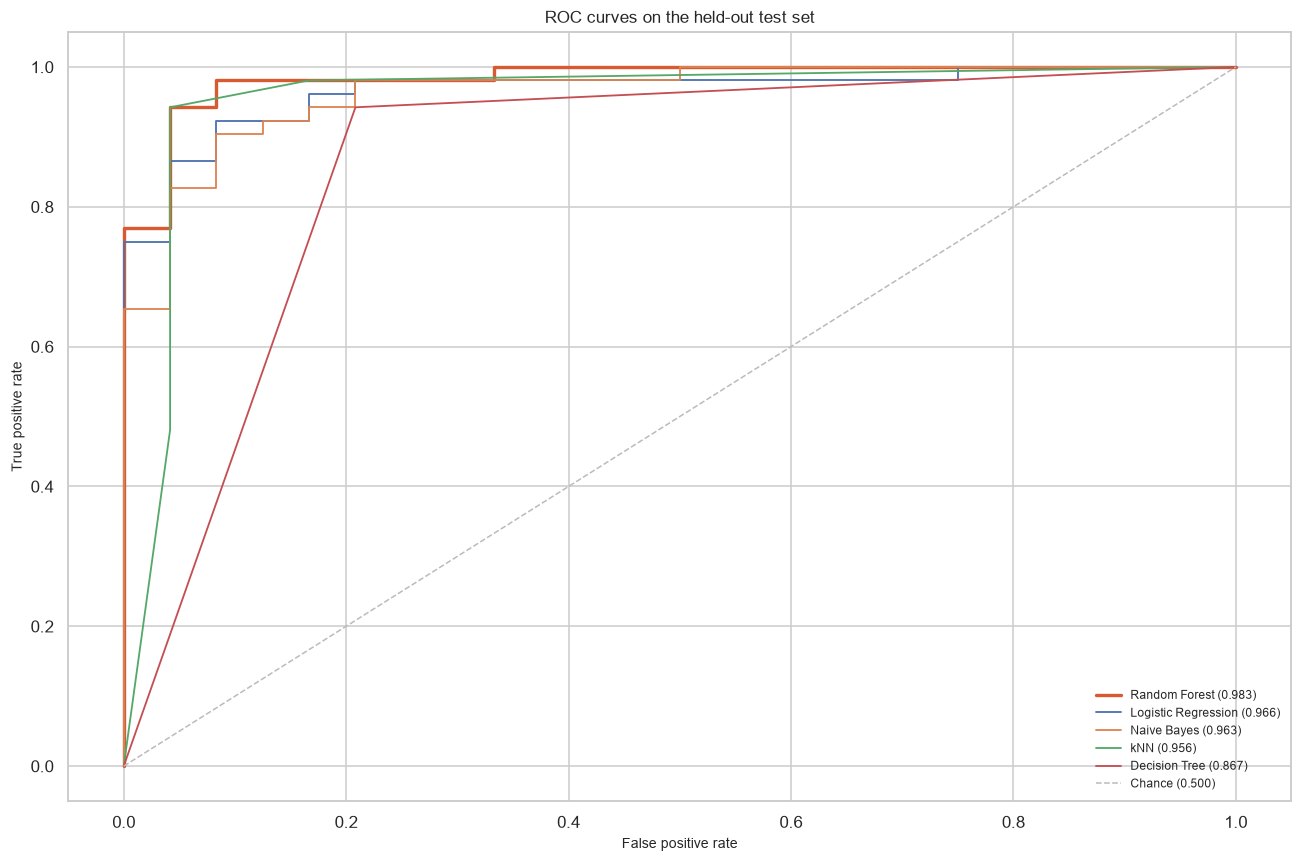

In [33]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(12, 8))
for name in results.sort_values("AUC", ascending=False).index:
    fpr, tpr, _ = roc_curve(y_test, pipelines[name].predict_proba(X_test)[:, 1])
    leading = name == results["AUC"].idxmax()
    ax.plot(fpr, tpr, label=f"{name} ({results.loc[name, 'AUC']:.3f})",
            linewidth=2.2 if leading else 1.2, color=ACCENT if leading else None)

ax.plot([0, 1], [0, 1], "--", color="#bbb", linewidth=1, label="Chance (0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the held-out test set")
ax.legend(fontsize=8, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

### 4.3 Confusion matrices

All five models on the same 76 held-out records, ordered by MCC. Rows are the true class, columns
the predicted one, so the off-diagonal top-right cell counts false positives and the bottom-left
cell counts missed cases.

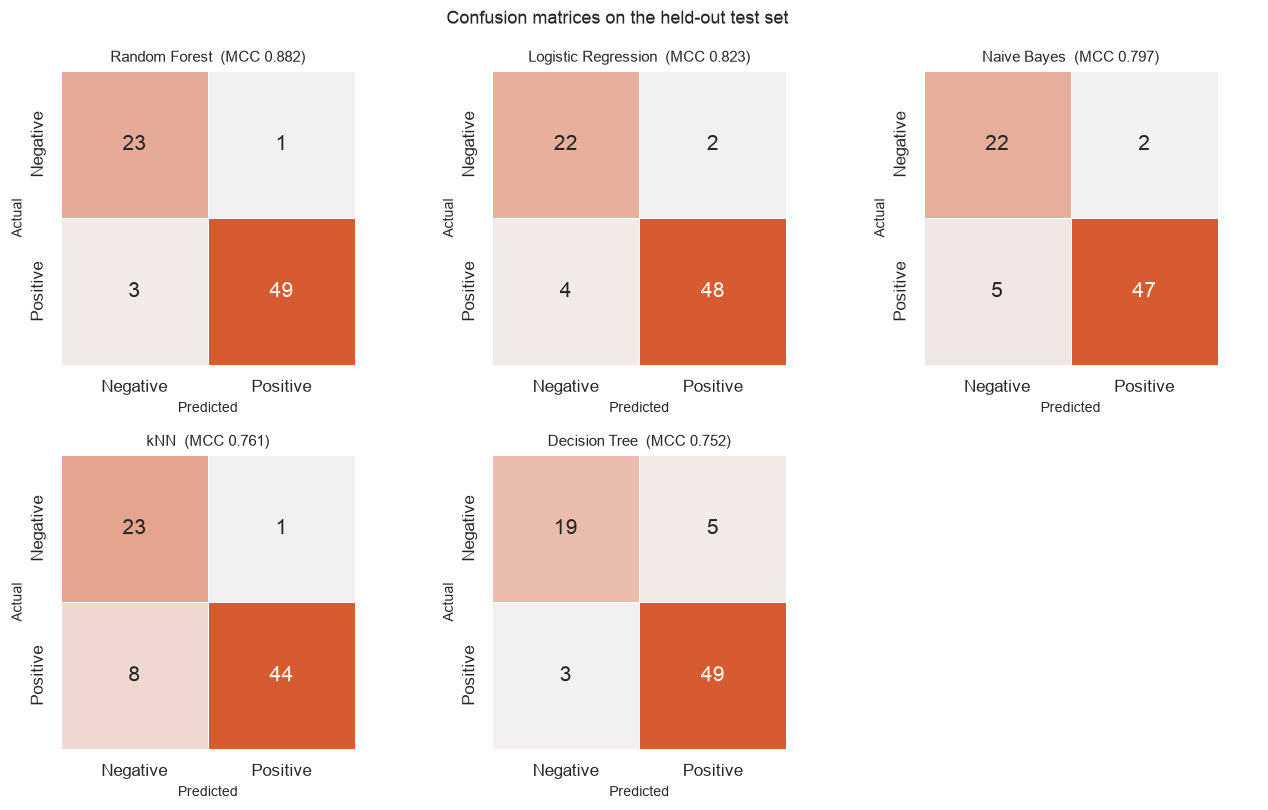

In [34]:
from sklearn.metrics import confusion_matrix

order = results.sort_values("MCC", ascending=False).index

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
for ax, name in zip(axes.ravel(), order):
    sns.heatmap(
        confusion_matrix(y_test, pipelines[name].predict(X_test)),
        annot=True, fmt="d", cbar=False, square=True,
        cmap=sns.light_palette(ACCENT, as_cmap=True),
        xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"],
        linewidths=0.5, linecolor="white", annot_kws={"size": 14}, ax=ax,
    )
    ax.set_title(f"{name}  (MCC {results.loc[name, 'MCC']:.3f})", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)

axes.ravel()[-1].axis("off")
fig.suptitle("Confusion matrices on the held-out test set", fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
cells = {}
for name in order:
    tn, fp, fn, tp = confusion_matrix(y_test, pipelines[name].predict(X_test)).ravel()
    cells[name] = {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Missed cases": fn, "Unnecessary tests": fp, "Total errors": fp + fn,
    }

pd.DataFrame(cells).T

,TN,FP,FN,TP,Missed cases,Unnecessary tests,Total errors
Random Forest,23,1,3,49,3,1,4
Logistic Regression,22,2,4,48,4,2,6
Naive Bayes,22,2,5,47,5,2,7
kNN,23,1,8,44,8,1,9
Decision Tree,19,5,3,49,3,5,8


The five models make between four and nine errors on the same 76 records, and distribute them
differently. The two directions do not cost the same: a missed case receives no follow-up, while a
false positive costs one unnecessary blood test.

k-nearest neighbours is the clearest illustration. It ties the random forest for the fewest false
positives at one, yet makes the most missed cases at eight - the least useful trade for a
screening instrument. The decision tree errs in the opposite direction, with the most false
positives at five but joint-fewest missed cases. The random forest makes the fewest errors overall
and is joint-best on missed cases, which is why it leads on both recall and MCC.

## 5. Observations

Held-out results are in section 4.1 and the ROC curves in section 4.2. The duplicate-record
finding that shapes the split is in section 1.3, and the correlation bearing on naive Bayes is in
section 1.5.

| Model | Observation |
|---|---|
| **Logistic regression** | The strongest of the four non-ensemble models, at 0.9211 accuracy and 0.8228 MCC. A linear boundary in log-odds is a reasonable fit when 15 of 16 features are binary, and its AUC of 0.9655 is second only to the ensemble, so it ranks cases nearly as well as it classifies them. Its coefficients should not be read as feature importances: polyuria and polydipsia correlate at 0.60, and collinear predictors divide one signal between them arbitrarily. |
| **Decision tree** | 0.8947 accuracy but 0.8670 AUC, the weakest ranking of the five by a clear margin. Grown to full depth every leaf is pure, so the tree emits only 0.0 or 1.0 as a probability and has no way to express degrees of confidence; AUC, which works by ranking cases, is left with almost nothing to order. Its hard predictions are unharmed, which is why the gap between its accuracy and its AUC is wider than any other model's. Structurally it suits the data well, since axis-aligned splits on binary indicators are what a symptom checklist encodes. |
| **k-nearest neighbours** | Lowest accuracy of the five at 0.8816. It is by far the model most sensitive to the scaling decision taken in section 2: age spans 16-90 against 15 0/1 columns and so accounts for the overwhelming majority of an unscaled Euclidean distance, while separating the classes least well of any feature. Unscaled, neighbours would be ranked almost entirely on the least informative input. Its precision of 0.9778 is second highest while its recall of 0.8462 is the lowest, so its errors fall disproportionately on missed cases. |
| **Gaussian naive Bayes** | 0.9079 accuracy and 0.7969 MCC, better than its assumptions predict. The violation was identified in section 1.5 before any model was fitted: conditional independence is assumed, yet the two strongest predictors correlate at 0.60, so treating them as independent evidence counts substantially the same signal twice. The ranking survives it - AUC 0.9631, effectively tied with logistic regression - because overconfidence distorts the magnitude of the posteriors more than their order, and AUC depends only on order. |
| **Random forest** | Best or joint-best on all 6 metrics, winning 5 outright and tying the decision tree on recall at 0.9423. Averaging many decorrelated trees removes the single tree's variance while keeping its aptitude for axis-aligned splits. It is also the clearest illustration of why the ensemble helps here: a hundred trees voting produce a graded probability across dozens of levels where one tree produces only 0 or 1, which is exactly how the weakest AUC of the 5 becomes the strongest. |
| **Overall winner** | **Random forest.** It is best or joint-best on every one of the 6 metrics, and leads on both the threshold-dependent measures and the threshold-independent one, so the result does not depend on where the decision boundary is drawn. Two qualifications belong with it. Duplicate response profiles were removed before splitting, so no test record appears in training and these figures measure generalisation rather than recall of memorised rows. And two symptom features nearly restate the diagnosis, so the task is easier than any of these numbers suggest. Logistic regression is preferable where interpretability or calibration matters more than the last few points of MCC. |

Every model clears the 0.6842 majority-class baseline by a wide margin. That reflects the dataset
rather than the modelling, and a high score here is the expected result for a correctly
implemented classifier rather than evidence of an unusually good one.

## 6. Persistence

The fitted pipelines are written by `model/train.py`, which is the reproducible entry point for
the whole analysis. Anything a pickled pipeline references must be importable from `src/` rather
than defined in a notebook cell: joblib records the class by import path, so an object defined
here would resolve to `__main__` and fail to load inside the deployed application.

In [36]:
import json

from src.config import METADATA_PATH

metadata = json.loads(METADATA_PATH.read_text())

print(f"{metadata['student_name']} - {metadata['student_id']}")
print(f"scikit-learn {metadata['sklearn_version']} on Python {metadata['python_version']}")
print(f"seed {metadata['seed']}, {metadata['n_train']} train / {metadata['n_test']} test, "
      f"deduplicated={metadata['deduplicated']}")
print("\nMetrics recorded alongside the saved models:")
pd.DataFrame(metadata["metrics"]).T[METRIC_ORDER].round(4)

Murlidhar Ravi Geetha Varma - 2025AC05598
scikit-learn 1.7.2 on Python 3.12.12
seed 5598, 175 train / 76 test, deduplicated=True

Metrics recorded alongside the saved models:


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9211,0.9655,0.9600,0.9231,0.9412,0.8228
Decision Tree,0.8947,0.8670,0.9074,0.9423,0.9245,0.7523
kNN,0.8816,0.9555,0.9778,0.8462,0.9072,0.7609
Naive Bayes,0.9079,0.9631,0.9592,0.9038,0.9307,0.7969
Random Forest,0.9474,0.9832,0.9800,0.9423,0.9608,0.8824
